# Materials Project Dataset

Explores the dataset fetched by `scripts/fetch_mp_dataset.py`. 

1. How many materials have property data?
2. What does the distribution of target property values look like?
3. Which chemical systems and elements dominate?
4. How do ionic vs electronic contributions compare?
5. What are the outliers and what should we watch out for during training?

**Prerequisite:** Run `scripts/fetch_mp_dataset.py` -> `mp_materials.json`

In [2]:
from __future__ import annotations

import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1. Load the data

In [3]:
JSON_PATH = Path("../mp_materials.json")

with open(JSON_PATH) as f:
    records = json.load(f)

df = pd.DataFrame.from_records(records)

# Drop internal bookkeeping columns
drop_cols = [c for c in df.columns if c in ("fields_not_requested", "origins", "deprecation_reasons", "deprecated")]
df = df.drop(columns=drop_cols, errors="ignore")

print(f"Dataset: {len(df)} materials")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset: 7327 materials
Columns: ['nsites', 'nelements', 'formula_pretty', 'chemsys', 'volume', 'density', 'symmetry', 'property_name', 'material_id', 'total', 'ionic', 'electronic', 'e_total', 'e_ionic', 'e_electronic', 'n', 'structure', 'band_gap', 'energy_above_hull']


,nsites,nelements,formula_pretty,chemsys,volume,density,symmetry,property_name,material_id,total,ionic,electronic,e_total,e_ionic,e_electronic,n,structure,band_gap,energy_above_hull
0,12,2,GeSe2,Ge-Se,355.647383,4.305994,"{'crystal_system': 'Tetragonal', 'symbol': 'I-...",dielectric,mp-10074,"[[9.947464435000002, 0.0, 0.0], [0.0, 9.947464...","[[2.982790645, 0.0, 0.0], [0.0, 2.982790645, 0...","[[6.964673790000003, 0.0, 0.0], [0.0, 6.964673...",10.346474,3.207224,7.139250,2.671937,"{'@module': 'pymatgen.core.structure', '@class...",1.5188,0.012494
1,12,2,P2Ir,Ir-P,185.987232,9.076970,"{'crystal_system': 'Monoclinic', 'symbol': 'P2...",dielectric,mp-10155,"[[23.14952549853399, 0.0, -0.968037853160115],...","[[6.277993618456594, 0.0, -0.397095810425072],...","[[16.871531880077395, 0.0, -0.570942042735043]...",22.526053,5.761588,16.764465,4.094443,"{'@module': 'pymatgen.core.structure', '@class...",0.6331,0.000000
2,12,2,LaAs2,As-La,305.558521,6.276748,"{'crystal_system': 'Monoclinic', 'symbol': 'P2...",dielectric,mp-1102055,"[[22.716867954766755, 0.0, -4.6946884671503035...","[[4.924862137438861, 0.0, -3.180372950869098],...","[[17.792005817327894, 0.0, -1.514315516281206]...",25.503259,6.076320,19.426939,4.407600,"{'@module': 'pymatgen.core.structure', '@class...",0.1840,0.000000
3,3,2,BaO2,Ba-O,52.146887,5.391925,"{'crystal_system': 'Tetragonal', 'symbol': 'I4...",dielectric,mp-1105,"[[17.233496977484222, 2.204500864411152e-06, -...","[[13.767642406444892, 1.761150370871433e-06, -...","[[3.46585457103933, 4.433504935397181e-07, -6....",17.105401,13.585526,3.519875,1.876133,"{'@module': 'pymatgen.core.structure', '@class...",2.2352,0.000000
4,20,2,ZrF4,F-Zr,252.113230,4.405503,"{'crystal_system': 'Monoclinic', 'symbol': 'P2...",dielectric,mp-1105223,"[[13.636115879329628, 0.0, -0.4700055172957930...","[[10.656941849105062, 0.0, -0.458504038207357]...","[[2.979174030224566, 0.0, -0.011501479088436],...",11.195834,8.310767,2.885068,1.698549,"{'@module': 'pymatgen.core.structure', '@class...",5.3453,0.000000


## 2. Quick stats on the scalar targets

This dataset gives us three scalars:
- **`e_total`** — total static dielectric constant (ε₁ at ω→0)
- **`e_ionic`** — ionic (lattice vibration) contribution
- **`e_electronic`** — electronic (optical) contribution
- **`n`** — refractive index (√e_electronic)

In [13]:
target_cols = ["e_total", "e_ionic", "e_electronic", "n"]
df[target_cols].describe().round(2)

,e_total,e_ionic,e_electronic,n
count,7327.00,7327.00,7327.00,7327.00
mean,50.74,32.33,18.41,2.43
std,1650.92,1484.16,624.08,3.54
min,1.16,0.00,-64.84,0.00
25%,7.91,3.99,2.94,1.71
50%,11.64,6.46,4.25,2.06
75%,18.95,11.35,6.53,2.56
max,126575.32,126567.27,46857.91,216.47


## 3. Distribution of e_total

The target property spans many orders of magnitude. A log-scale view is essential:

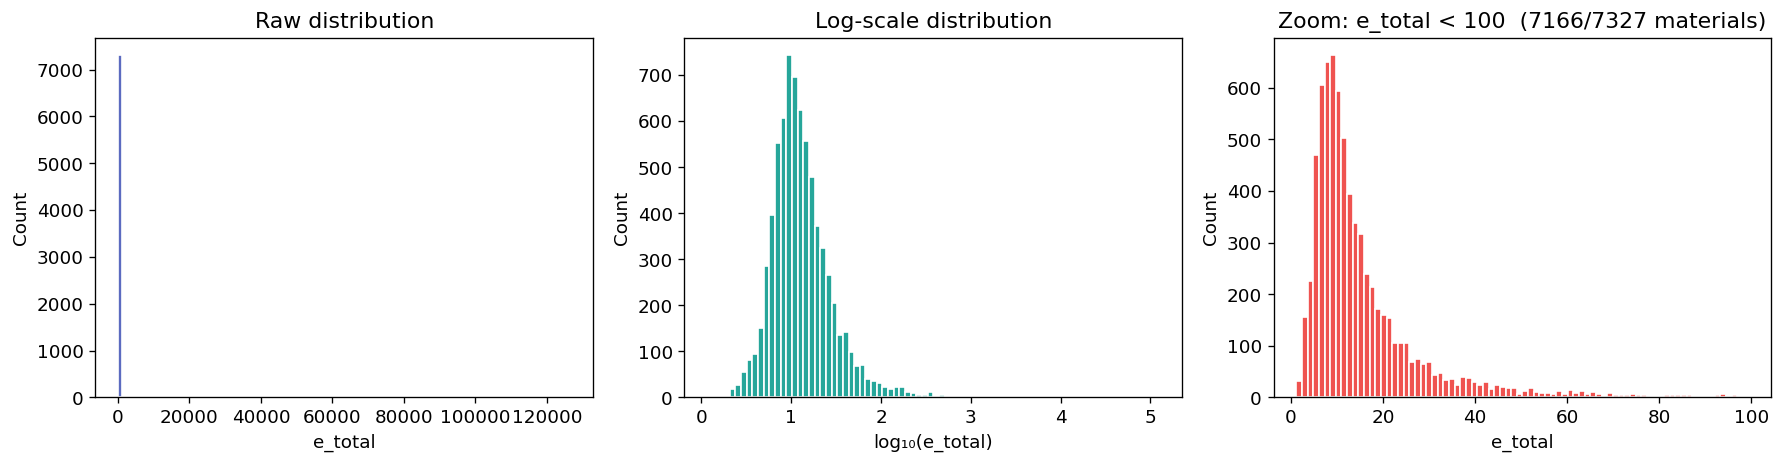


Percentiles of e_total:
   25th:       7.91
   50th:      11.64
   75th:      18.95
   90th:      34.10
   95th:      53.37
   99th:     180.64


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Raw histogram
axes[0].hist(df["e_total"], bins=100, edgecolor="white", color="#5C6BC0")
axes[0].set_xlabel("e_total")
axes[0].set_ylabel("Count")
axes[0].set_title("Raw distribution")

# (b) Log-scale histogram
log_e = np.log10(df["e_total"].clip(lower=1e-3))
axes[1].hist(log_e, bins=80, edgecolor="white", color="#26A69A")
axes[1].set_xlabel("log₁₀(e_total)")
axes[1].set_ylabel("Count")
axes[1].set_title("Log-scale distribution")

# (c) Zoom: e_total < 100 (where most materials live)
subset = df[df["e_total"] < 100]
axes[2].hist(subset["e_total"], bins=80, edgecolor="white", color="#EF5350")
axes[2].set_xlabel("e_total")
axes[2].set_ylabel("Count")
axes[2].set_title(f"Zoom: e_total < 100  ({len(subset)}/{len(df)} materials)")

plt.tight_layout()
plt.show()

print(f"\nPercentiles of e_total:")
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  {p:>3d}th: {df['e_total'].quantile(p/100):>10.2f}")

### Paper-style histograms (ε total & ε ionic)

The figures below reproduce the histogram style from Petousis et al. (2017), who reported **6,878** dielectric entries in the Materials Project at the time. Our current dataset is larger, but the distributions have the same shape. This confirms that `e_total` ≡ ε_total and `e_ionic` ≡ ε_ionic.

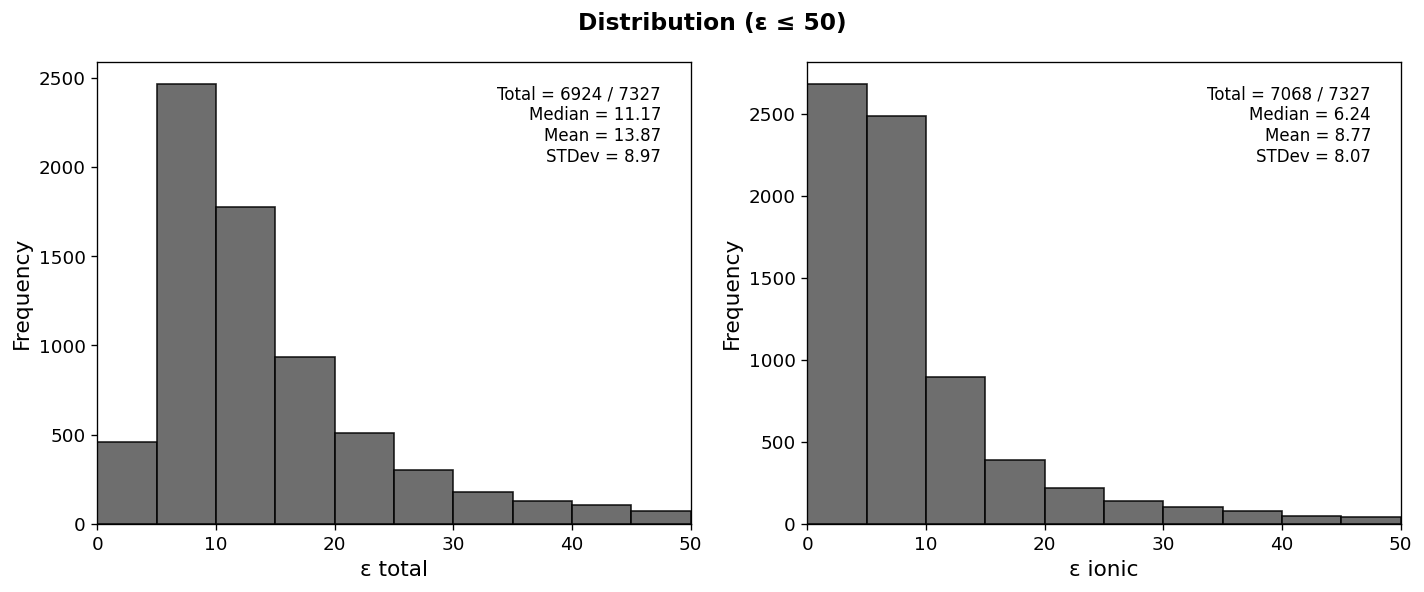

  ε total: 403 materials (5.5%) have values > 50 (excluded from plot)
  ε ionic: 259 materials (3.5%) have values > 50 (excluded from plot)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bins = np.arange(0, 55, 5)

for ax, col, label in zip(axes, ["e_total", "e_ionic"], ["ε total", "ε ionic"]):
    vals = df[col]
    clipped = vals[vals <= 50]
    ax.hist(clipped, bins=bins, edgecolor="black", color="#555555", alpha=0.85)
    ax.set_xlabel(label, fontsize=13)
    ax.set_ylabel("Frequency", fontsize=13)
    ax.set_xlim(0, 50)

    # Stats over the ≤50 subset
    total = len(clipped)
    med = clipped.median()
    std = clipped.std()
    stats_text = (f"Total = {total} / {len(vals)}\nMedian = {med:.2f}\n"
                  f"Mean = {clipped.mean():.2f}\nSTDev = {std:.2f}")
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment="top", horizontalalignment="right",
            bbox=dict(boxstyle="square,pad=0.3", facecolor="white", edgecolor="none", alpha=0.8))

plt.suptitle("Distribution (ε ≤ 50)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# How many materials are excluded
for col, label in [("e_total", "ε total"), ("e_ionic", "ε ionic")]:
    n_all = len(df[col])
    n_over = (df[col] > 50).sum()
    print(f"  {label}: {n_over} materials ({100*n_over/n_all:.1f}%) have values > 50 (excluded from plot)")

## 4. Ionic vs electronic contributions

The total dielectric constant is the sum of ionic and electronic parts. High-ε materials typically have a large *ionic* contribution (soft phonon modes):

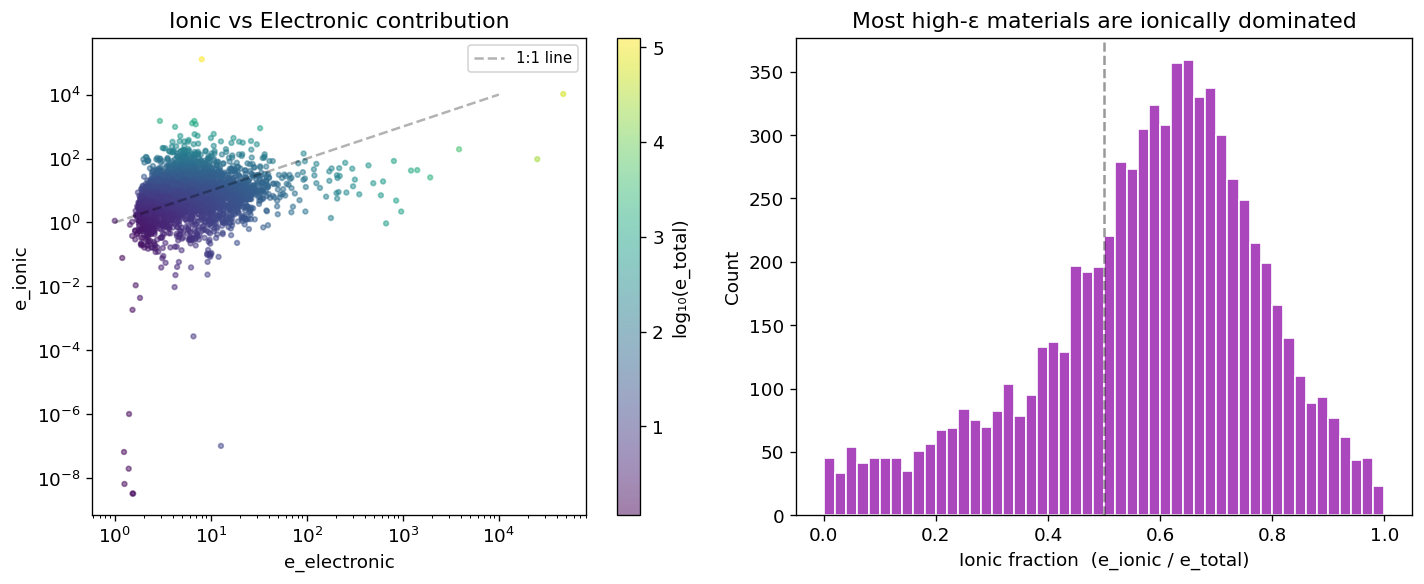

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Scatter: ionic vs electronic
ax = axes[0]
sc = ax.scatter(
    df["e_electronic"], df["e_ionic"],
    c=np.log10(df["e_total"].clip(lower=1)),
    s=8, alpha=0.5, cmap="viridis",
)
ax.set_xlabel("e_electronic")
ax.set_ylabel("e_ionic")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Ionic vs Electronic contribution")
ax.plot([1, 1e4], [1, 1e4], "k--", alpha=0.3, label="1:1 line")
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label="log₁₀(e_total)")

# (b) Fraction that is ionic
ionic_frac = df["e_ionic"] / df["e_total"]
ax2 = axes[1]
ax2.hist(ionic_frac.clip(0, 1), bins=50, edgecolor="white", color="#AB47BC")
ax2.set_xlabel("Ionic fraction  (e_ionic / e_total)")
ax2.set_ylabel("Count")
ax2.set_title("Most high-ε materials are ionically dominated")
ax2.axvline(0.5, color="k", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 5. Chemical systems and elements

Which elements appear most often among materials with property data? Which chemical systems are best represented?

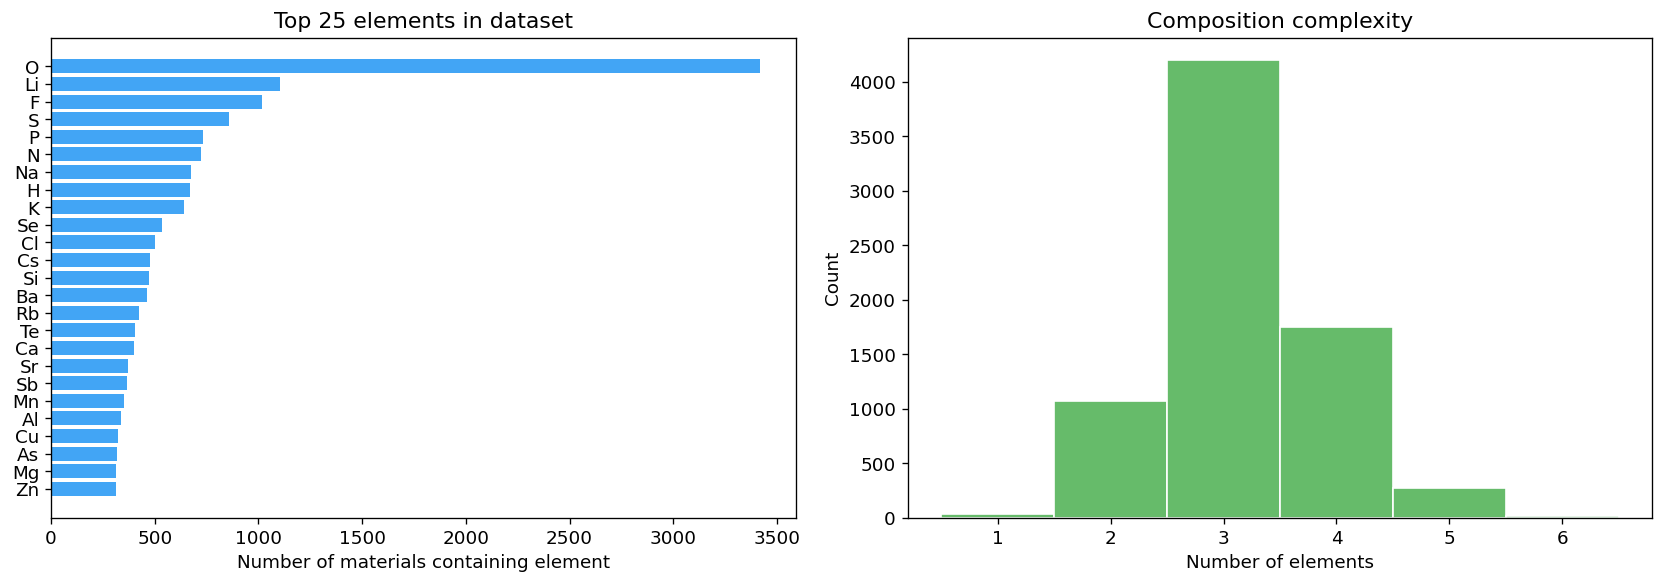


Total unique elements: 80
Most common: O, Li, F, S, P, N, Na, H, K, Se


In [9]:
# Count individual elements across all chemsys
element_counter = Counter()
for chemsys in df["chemsys"]:
    for el in chemsys.split("-"):
        element_counter[el] += 1

top_elements = element_counter.most_common(25)
elems, counts = zip(*top_elements)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Top elements
ax = axes[0]
ax.barh(range(len(elems)), counts, color="#42A5F5")
ax.set_yticks(range(len(elems)))
ax.set_yticklabels(elems)
ax.invert_yaxis()
ax.set_xlabel("Number of materials containing element")
ax.set_title("Top 25 elements in dataset")

# (b) Number of elements per material
ax2 = axes[1]
ax2.hist(df["nelements"], bins=range(1, df["nelements"].max() + 2), edgecolor="white",
         color="#66BB6A", align="left")
ax2.set_xlabel("Number of elements")
ax2.set_ylabel("Count")
ax2.set_title("Composition complexity")
ax2.set_xticks(range(1, df["nelements"].max() + 1))

plt.tight_layout()
plt.show()

print(f"\nTotal unique elements: {len(element_counter)}")
print(f"Most common: {', '.join(elems[:10])}")

## 6. Structure size distribution

The number of sites (atoms in the unit cell) directly affects graph size and training cost:

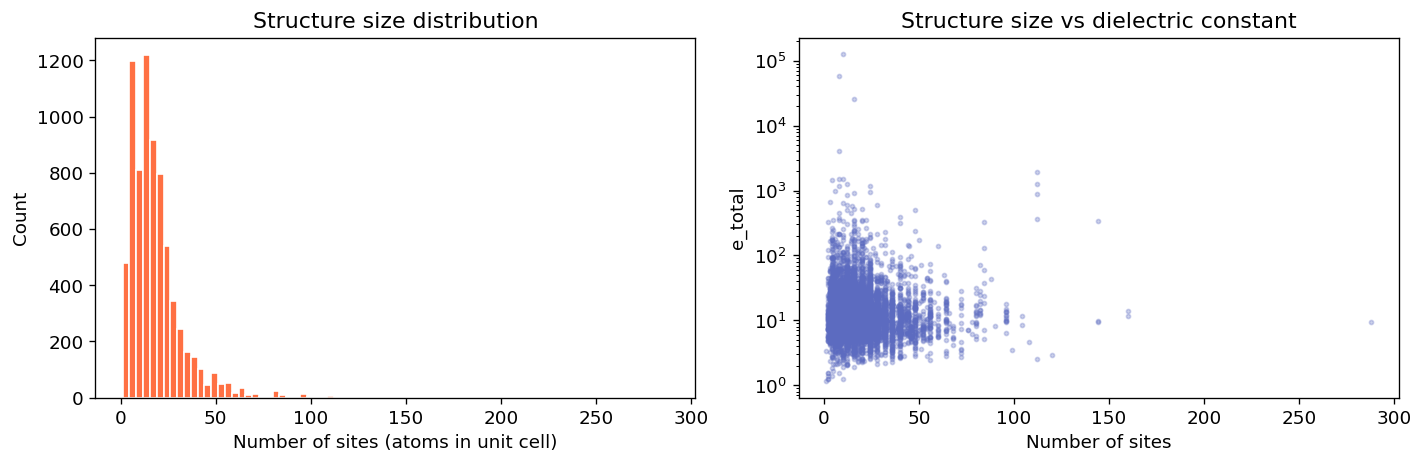

Sites — median: 15, mean: 18.4, max: 288


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) nsites distribution
ax = axes[0]
ax.hist(df["nsites"], bins=80, edgecolor="white", color="#FF7043")
ax.set_xlabel("Number of sites (atoms in unit cell)")
ax.set_ylabel("Count")
ax.set_title("Structure size distribution")

# (b) nsites vs e_total
ax2 = axes[1]
ax2.scatter(df["nsites"], df["e_total"], s=6, alpha=0.3, c="#5C6BC0")
ax2.set_xlabel("Number of sites")
ax2.set_ylabel("e_total")
ax2.set_yscale("log")
ax2.set_title("Structure size vs target property")

plt.tight_layout()
plt.show()

print(f"Sites — median: {df['nsites'].median():.0f}, "
      f"mean: {df['nsites'].mean():.1f}, max: {df['nsites'].max()}")

## 7. High-ε materials — what are they?

Let's look at the materials with the highest target property values. These are typically ferroelectric perovskites and related structures:

In [8]:
display_cols = ["material_id", "formula_pretty", "chemsys", "nsites",
                "e_total", "e_ionic", "e_electronic", "n"]

print("=== Top 20 by e_total ===")
top20 = df.nlargest(20, "e_total")[display_cols].reset_index(drop=True)
display(top20)

print("\n=== Top 10 by e_electronic (optical dielectric) ===")
top10_elec = df.nlargest(10, "e_electronic")[display_cols].reset_index(drop=True)
display(top10_elec)

=== Top 20 by e_total ===


,material_id,formula_pretty,chemsys,nsites,e_total,e_ionic,e_electronic,n
0,mp-bjbuw,CsSnI3,Cs-I-Sn,10,126575.316823,126567.273642,8.043181,2.836050
1,mp-dbf,NbAs,As-Nb,8,57262.630716,10404.720206,46857.910510,216.466881
2,mp-bghpc,CdSb2Se3Br2,Br-Cd-Sb-Se,16,25244.446111,95.629586,25148.816525,158.583784
3,mp-bhqm,InCuS2,Cu-In-S,8,4046.898274,195.082603,3851.815672,62.062998
4,mp-bpdlh,Zr3Zn3N,N-Zn-Zr,112,1953.862159,25.632271,1928.229887,43.911614
5,mp-bqwtn,LiVF6,F-Li-V,8,1501.911610,1498.960550,2.951059,1.717865
6,mp-oqk,TaAgO3,Ag-O-Ta,10,1501.073704,1494.344015,6.729689,2.594164
7,mp-bxiyk,CaMgTl2,Ca-Mg-Tl,4,1455.211393,43.410269,1411.801124,37.573942
8,mp-bfbfd,WO3,O-W,12,1273.229423,1266.841423,6.388000,2.527449
9,mp-bpdkj,Hf3Zn3N,Hf-N-Zn,112,1258.840822,42.026733,1216.814089,34.882862



=== Top 10 by e_electronic (optical dielectric) ===


,material_id,formula_pretty,chemsys,nsites,e_total,e_ionic,e_electronic,n
0,mp-dbf,NbAs,As-Nb,8,57262.630716,10404.720206,46857.910510,216.466881
1,mp-bghpc,CdSb2Se3Br2,Br-Cd-Sb-Se,16,25244.446111,95.629586,25148.816525,158.583784
2,mp-bhqm,InCuS2,Cu-In-S,8,4046.898274,195.082603,3851.815672,62.062998
3,mp-bpdlh,Zr3Zn3N,N-Zn-Zr,112,1953.862159,25.632271,1928.229887,43.911614
4,mp-bxiyk,CaMgTl2,Ca-Mg-Tl,4,1455.211393,43.410269,1411.801124,37.573942
5,mp-bpdkj,Hf3Zn3N,Hf-N-Zn,112,1258.840822,42.026733,1216.814089,34.882862
6,mp-zf,Na3As,As-Na,24,963.340396,2.199834,961.140562,31.002267
7,mp-ckisp,YAsSe,As-Se-Y,12,856.798534,4.853354,851.945180,29.188100
8,mp-bqci,Fe3W3N,Fe-N-W,112,889.926868,83.721441,806.205427,28.393757
9,mp-hiy,YSbPt,Pt-Sb-Y,3,669.672961,0.935531,668.737430,25.859958


## 8. Dielectric tensor — it's not just a scalar

The JSON also stores the full 3×3 dielectric tensor. The scalar `e_total` is the average of the diagonal. Let's verify this and look at anisotropy:

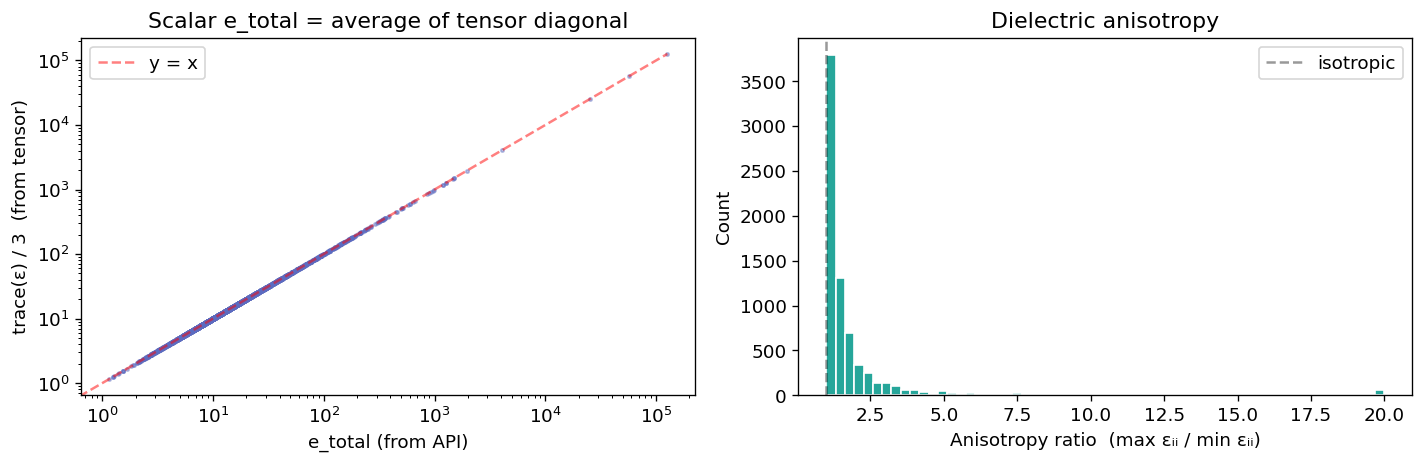

Perfectly isotropic (ratio < 1.01): 1020 / 7327
Highly anisotropic (ratio > 5):     364 / 7327


In [9]:
# Parse the 3×3 total tensor
tensors = []
for rec in records:
    t = rec.get("total")
    if t and len(t) == 3:
        tensors.append(np.array(t))
tensors = np.array(tensors)  # (N, 3, 3)

# Diagonal elements
diag = np.array([tensors[:, i, i] for i in range(3)]).T  # (N, 3)
trace_avg = diag.mean(axis=1)

# Anisotropy: max diagonal / min diagonal
anisotropy = diag.max(axis=1) / diag.min(axis=1).clip(min=1e-6)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Verify trace/3 ≈ e_total
ax = axes[0]
ax.scatter(df["e_total"][:len(trace_avg)], trace_avg, s=4, alpha=0.4, c="#5C6BC0")
lim = max(df["e_total"].max(), trace_avg.max())
ax.plot([0, lim], [0, lim], "r--", alpha=0.5, label="y = x")
ax.set_xlabel("e_total (from API)")
ax.set_ylabel("trace(ε) / 3  (from tensor)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Scalar e_total = average of tensor diagonal")
ax.legend()

# (b) Anisotropy distribution
ax2 = axes[1]
ax2.hist(np.clip(anisotropy, 0, 20), bins=60, edgecolor="white", color="#26A69A")
ax2.set_xlabel("Anisotropy ratio  (max εᵢᵢ / min εᵢᵢ)")
ax2.set_ylabel("Count")
ax2.set_title("Dielectric anisotropy")
ax2.axvline(1.0, color="k", linestyle="--", alpha=0.4, label="isotropic")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Perfectly isotropic (ratio < 1.01): {(anisotropy < 1.01).sum()} / {len(anisotropy)}")
print(f"Highly anisotropic (ratio > 5):     {(anisotropy > 5).sum()} / {len(anisotropy)}")

## 9. Correlations between features

Quick look at which structural features correlate with the target property:

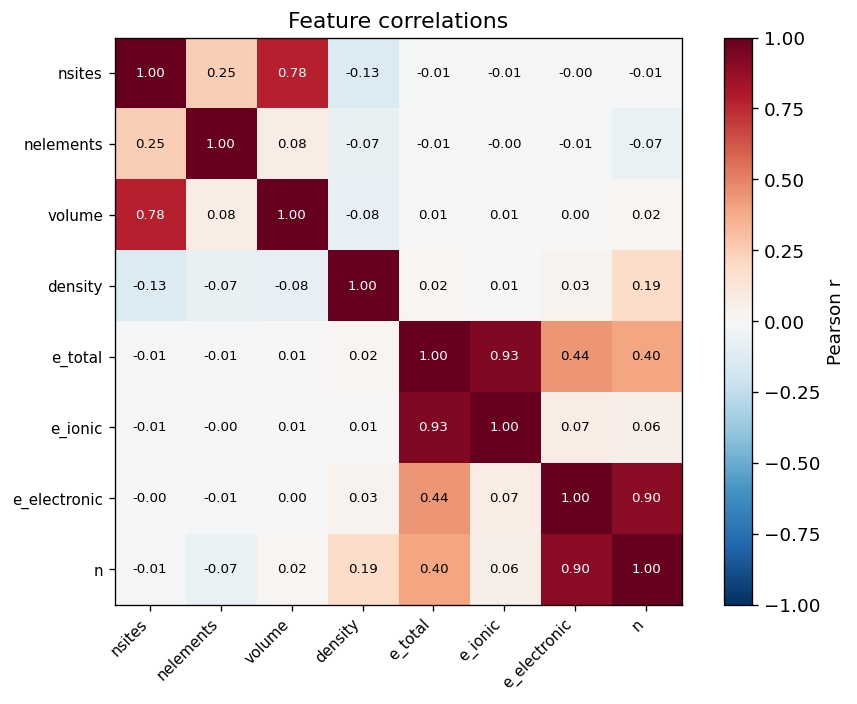

In [10]:
numeric_cols = ["nsites", "nelements", "volume", "density", "e_total", "e_ionic", "e_electronic", "n"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(numeric_cols, fontsize=9)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")

plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Feature correlations")
plt.tight_layout()
plt.show()

## 10. Data quality checks for ML

Things to be aware of before training:

In [11]:
has_structure = df["structure"].notna() & (df["structure"] != None)  # noqa: E711

print("=== Data Quality Report ===\n")
print(f"  Total records          : {len(df)}")
print(f"  With structure         : {has_structure.sum()}")
print(f"  Missing structure      : {(~has_structure).sum()}")
print(f"  e_total NaN/null       : {df['e_total'].isna().sum()}")
print(f"  e_total ≤ 0            : {(df['e_total'] <= 0).sum()}")
print(f"  e_total > 10,000       : {(df['e_total'] > 10_000).sum()}  (likely outliers)")
print(f"  Duplicate material_id  : {df['material_id'].duplicated().sum()}")
print()

if has_structure.sum() == 0:
    print("  ⚠ No structures in the JSON yet!")
    print("    Re-run: python scripts/fetch_data.py  (or scripts/fetch_mp_dataset.py)")
    print("    The fixed script will fetch structures from the summary endpoint.")
else:
    print("  ✓ Structures present — ready for graph conversion and training.")

=== Data Quality Report ===

  Total records          : 7327
  With structure         : 0
  Missing structure      : 7327
  e_total NaN/null       : 0
  e_total ≤ 0            : 0
  e_total > 10,000       : 3  (likely outliers)
  Duplicate material_id  : 0

  ⚠ No structures in the JSON yet!
    Re-run: python scripts/fetch_data.py  (or scripts/fetch_mp_dielectric_dataset.py)
    The fixed script will fetch structures from the summary endpoint.


## 11. Target transformation for training

The extreme skew and outliers in `e_total` will make MSE training difficult. Common strategies:

- **Log transform**: `log₁₀(e_total)` — compresses the range, makes the distribution more normal
- **Clip outliers**: remove or cap materials with e_total > some threshold
- **Robust scaling**: subtract median, divide by IQR

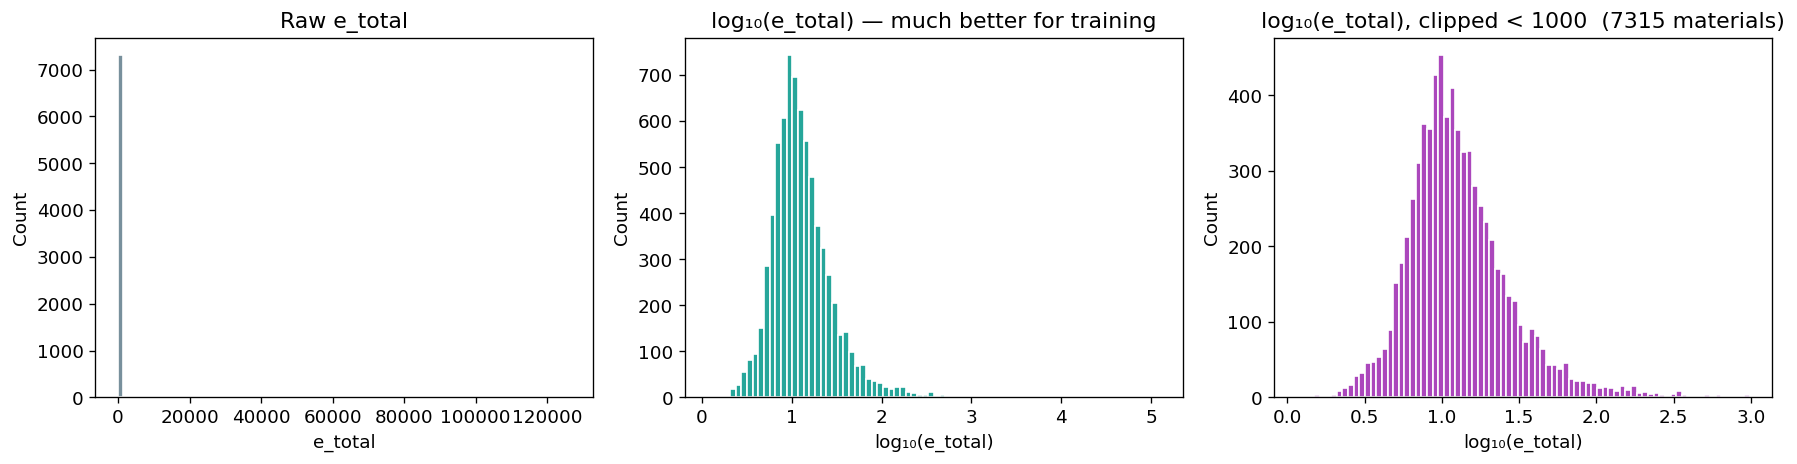


Recommendation: use log₁₀(e_total) as the training target.
After clipping e_total < 1000: 7315 materials remain (99.8%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Raw
axes[0].hist(df["e_total"], bins=100, edgecolor="white", color="#78909C")
axes[0].set_title("Raw e_total")
axes[0].set_xlabel("e_total")

# (b) log₁₀
log_e = np.log10(df["e_total"].clip(lower=1e-3))
axes[1].hist(log_e, bins=80, edgecolor="white", color="#26A69A")
axes[1].set_title("log₁₀(e_total) — much better for training")
axes[1].set_xlabel("log₁₀(e_total)")

# (c) Clipped + log₁₀
clipped = df[df["e_total"] < 1000]["e_total"]
log_clipped = np.log10(clipped.clip(lower=1e-3))
axes[2].hist(log_clipped, bins=80, edgecolor="white", color="#AB47BC")
axes[2].set_title(f"log₁₀(e_total), clipped < 1000  ({len(clipped)} materials)")
axes[2].set_xlabel("log₁₀(e_total)")

for ax in axes:
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"\nRecommendation: use log₁₀(e_total) as the training target.")
print(f"After clipping e_total < 1000: {len(clipped)} materials remain ({100*len(clipped)/len(df):.1f}%)")

## Summary

| Finding | Implication for ML |
|---|---|
| ~7,300 materials with property data | Moderate-sized dataset — data efficiency matters |
| `e_total` spans 1 to 126,000+ | Must log-transform or clip; MSE on raw values is dominated by outliers |
| Most materials have e_total < 50 | Model will be biased toward low-ε; high-ε predictions need care |
| Ionic contribution dominates in high-ε | Predicting e_ionic alone may be harder (lattice dynamics are complex) |
| O is by far the most common element | Model will see many oxides; rare chemistries are underrepresented |
| Some materials are highly anisotropic | Scalar `e_total` loses directional information; tensor prediction is a harder but richer task |

**Next steps:**
- **Notebook 02** → understand how structures become graphs
- **Notebook 03** → train a GNN baseline on this data